# Регуляризація та функції активації в нейронних мережах

## Бізнес-контекст
Компанія HealthRisk Analytics продовжує покращувати модель прогнозування медичних ризиків.
Команда розробників хоче зрозуміти, як різні функції активації та прийоми регуляризації (Dropout, Batch Normalization) впливають на стабільність і якість навчання моделі. Ваше завдання — провести серію експериментів і порівняти результати.
## Завдання 1
Дослідіть вплив функцій активації на результати моделі.
- Згенеруйте синтетичні дані для регресії за допомогою функції make_regression (2000 рядків, 10 ознак, noise=10, random_state=42).
- Побудуйте модель MLP з одним прихованим прошарком із 32 нейронів.
- Послідовно застосуйте різні функції активації: ReLU, Tanh, LeakyReLU, Swish.
- Для кожної активації розрахуйте MAE і R² на тестовій вибірці.
- Оформіть результати в таблиці:

|Активація|MAE|R²|
|-|-|-|
|ReLU|...|..|
|Tanh|...|...
|LeakyReLU|...|...|
|Swish|...|...|

In [1]:
# підготовка даних:
# 1. Генерація
from sklearn.datasets import make_regression
X,y = make_regression(n_samples=2000, n_features=10, noise=10, random_state=42)
# 2. Поділ на навчальну та тестову групи
from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2)
# 3. Нормалізація (масштабування)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
xtrain = scaler.fit_transform(xtrain)
xtest = scaler.transform(xtest)
# 4. Перетворення на тензори, з якими працює нейромережа
import torch
xtrain = torch.tensor(xtrain, dtype=torch.float32)
xtest = torch.tensor(xtest, dtype=torch.float32)
ytrain = torch.tensor(ytrain, dtype=torch.float32).reshape(-1,1) * 0.01  # ручне масштабування
ytest = torch.tensor(ytest, dtype=torch.float32).reshape(-1,1) * 0.01    # без нього не всі моделі навчаються
xtrain[:5]

tensor([[ 0.5158,  0.8136, -0.3185,  0.4746,  0.2788, -0.4946, -0.2591,  0.0189,
          0.7157, -0.1413],
        [ 0.6766,  0.9645, -0.8178, -1.1144, -0.6190, -0.7662,  2.1693, -0.0481,
         -1.3204, -0.8208],
        [-1.5184, -1.6947, -0.5004, -0.2078, -0.9344, -0.9841, -0.9451, -0.4297,
         -1.5288,  0.5092],
        [-0.0988,  1.9180,  0.4563,  1.0785,  0.8280, -0.4385,  1.5098, -0.1374,
         -2.6214, -0.8384],
        [ 0.2132, -0.2933, -0.3992,  0.8501,  0.9657,  1.8224, -0.1326,  1.3103,
         -1.0534,  0.7180]])

In [2]:
# Готуємо різні функції активації
import torch.nn as nn
activators = {
    "Sigmoid": nn.Sigmoid(),
    "ReLU": nn.ReLU(),
    "Tanh": nn.Tanh(),
    "LeakyReLU": nn.LeakyReLU(),
    "SiLU": nn.SiLU(),
    "Swish": nn.SiLU(),
}

In [3]:
# Побудуйте модель MLP з одним прихованим прошарком із 32 нейронів.
class Mlp(nn.Module):
    def __init__(
        self, 
        input_size=10,      # S-elements (вхідний шар) / ознаки
        hidden_size=32,     # A-elements (прихований/внутрішній шар)
        output_size=1,      # R-elements (виходи)
        activation="ReLU"   # функція активації елементів
    ):
        super(Mlp, self).__init__()
        self.activation = activators.get(activation,None)
        if self.activation is None :
            raise ValueError(f"Undefined activator '{activation}'")
        self.layers = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            self.activation,
            nn.Linear(hidden_size, output_size),
        )

    def forward(self, x, mode='test') :
        return self.layers(x)
        

In [4]:
# Функція для навчання моделей
def train_model(model, X, y, epochs=1000, lr=0.01) :
    criterion = nn.functional.mse_loss
    optimizer = torch.optim.SGD(model.parameters(),lr=lr)
    losses = [*range(epochs)]
    for epoch in range(epochs) :
        output = model(X, 'train')   # model.forward(X)
        loss = criterion(output, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses[epoch] = loss.item()
    return losses    

In [5]:
# Послідовно застосуйте різні функції активації
mlps = { k: Mlp(activation=k) for k in activators.keys() }
# mlps

In [6]:
def train_models_set(mlps, xtrain, ytrain) :
    losses = {}
    predictions = {}
    for k, mlp in mlps.items() :
        losses[k] = train_model(mlp, xtrain, ytrain)  # навчаємо всі моделі та зберігаємо їх прогреси (втрати)
        with torch.no_grad() :
            predictions[k] = mlp(xtest)
    return losses, predictions        

In [7]:
losses, predictions = train_models_set(mlps, xtrain, ytrain)
print(*zip(*(predictions[k][:5] for k in mlps.keys() ), ytest[:5]),sep='\n')

(tensor([2.8007]), tensor([2.7527]), tensor([2.8460]), tensor([2.8051]), tensor([2.8671]), tensor([2.7463]), tensor([2.7220]))
(tensor([1.1913]), tensor([1.0575]), tensor([1.1944]), tensor([1.4552]), tensor([1.1047]), tensor([1.0648]), tensor([1.1580]))
(tensor([0.7463]), tensor([0.8029]), tensor([0.7780]), tensor([0.8701]), tensor([0.6592]), tensor([0.6362]), tensor([0.7431]))
(tensor([3.6236]), tensor([3.6357]), tensor([3.8100]), tensor([3.5025]), tensor([3.6615]), tensor([3.6705]), tensor([3.7869]))
(tensor([2.5460]), tensor([2.4255]), tensor([2.6574]), tensor([2.3906]), tensor([2.4471]), tensor([2.4640]), tensor([2.4418]))


Без масштабування вихідних даних (у) деякі моделі не проходять навчання
Функції активації типу ReLU не обмежені, через що відбувається переповнення коефіцієнтів 


In [8]:
from IPython.display import Markdown as md
import sklearn.metrics as sm

def score_table(ytest, predictions):
    return md("\n".join((
        "|Активація|MAE|R²|",
        "|-|-|-|",
        *(f"|{k}|{sm.mean_absolute_error(ytest,v)}|{sm.r2_score(ytest,v)}|" for k,v in predictions.items())
    )))

In [9]:
score_table(ytest, predictions)

|Активація|MAE|R²|
|-|-|-|
|Sigmoid|0.12703491747379303|0.9916929602622986|
|ReLU|0.13891658186912537|0.9924101233482361|
|Tanh|0.1453428864479065|0.98994380235672|
|LeakyReLU|0.13962674140930176|0.9923920035362244|
|SiLU|0.10314854979515076|0.9955152273178101|
|Swish|0.09358009696006775|0.996366560459137|

In [18]:
# Побудувати лінії втрат (losses) на одному графіку. Назви додати як легенду
import matplotlib.pyplot as plt
def plot_losses(losses):
    _,ax = plt.subplots()
    for k,v in losses.items() :
        ax.plot(v, label=k)
    ax.legend()    
    ax.grid()
    plt.show()

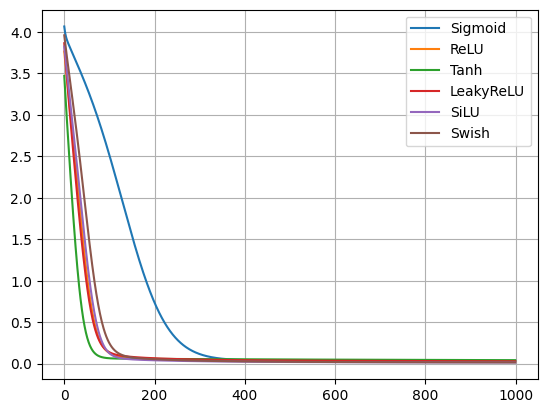

In [19]:
plot_losses(losses)

## Завдання 2
Додайте Dropout і проаналізуйте вплив регуляризації.
- Використовуйте ту саму архітектуру MLP.
- Додайте шар torch.nn.Dropout(p=0.3) після прихованого шару.
- Порівняйте результати до і після застосування Dropout за MAE і R².
- Зробіть висновок: чи допомагає Dropout уникнути перенавчання?

In [12]:
# Використовуйте ту саму архітектуру MLP.
class MlpDropout(nn.Module):
    def __init__(self,input_size=10,hidden_size=32,output_size=1,activation="ReLU"):
        super(MlpDropout, self).__init__()
        self.activation = activators.get(activation,None)
        if self.activation is None :
            raise ValueError(f"Undefined activator '{activation}'")
        # Dropout - методика випадкового вилучення нейронів під час навчання
        # її використання розрізняє процеси навчання та використання
        self.hidden  = nn.Linear(input_size, hidden_size)
        self.dropout = nn.Dropout(p=0.3)
        self.output  = nn.Linear(hidden_size, output_size)

    def forward(self, x, mode='test') :
        x = self.hidden(x)
        x = self.activation(x)
        if mode != 'test' :
            x = self.dropout(x)
        x = self.output(x)    
        return x
        

In [13]:
mlps_d = { k: MlpDropout(activation=k) for k in activators.keys() }
losses_d, predictions_d = train_models_set(mlps_d, xtrain, ytrain)
print(*zip(*(predictions_d[k][:5] for k in mlps_d.keys() ), ytest[:5]),sep='\n')
score_table(ytest, predictions_d)

(tensor([2.5770]), tensor([2.7065]), tensor([2.6906]), tensor([2.7344]), tensor([2.8112]), tensor([2.7368]), tensor([2.7220]))
(tensor([1.1223]), tensor([0.9797]), tensor([1.1572]), tensor([1.1072]), tensor([1.1303]), tensor([1.1225]), tensor([1.1580]))
(tensor([0.6312]), tensor([0.6365]), tensor([0.7368]), tensor([0.7105]), tensor([0.6198]), tensor([0.5660]), tensor([0.7431]))
(tensor([3.1145]), tensor([3.5171]), tensor([3.5986]), tensor([3.4536]), tensor([3.6007]), tensor([3.5446]), tensor([3.7869]))
(tensor([2.2386]), tensor([2.1661]), tensor([2.5069]), tensor([2.2660]), tensor([2.3007]), tensor([2.2958]), tensor([2.4418]))


|Активація|MAE|R²|
|-|-|-|
|Sigmoid|0.20463839173316956|0.9683191776275635|
|ReLU|0.1439465582370758|0.991224467754364|
|Tanh|0.13769273459911346|0.9887313842773438|
|LeakyReLU|0.1333203911781311|0.9921443462371826|
|SiLU|0.10280206799507141|0.995506763458252|
|Swish|0.10837335884571075|0.9949660301208496|

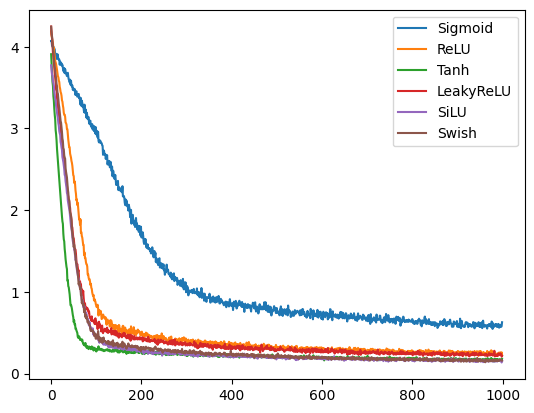

In [14]:
plot_losses(losses_d)

## Завдання 3
Додайте Batch Normalization для стабілізації навчання.
- Використовуйте шар torch.nn.BatchNorm1d після лінійного шару.
- Навчіть модель і побудуйте графік функції втрат за епохами.
- Порівняйте розкид loss з попередніми експериментами.

In [15]:
class MlpBatch(nn.Module):
    def __init__(self,input_size=10,hidden_size=32,output_size=1,activation="ReLU"):
        super(MlpBatch, self).__init__()
        self.activation = activators.get(activation,None)
        if self.activation is None :
            raise ValueError(f"Undefined activator '{activation}'")
        # Batch Normalization - методика перерахунку вагових коефіцієнтів
        # з метою упередження їх занулення або "вибуху"
        self.layers = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.BatchNorm1d(hidden_size),
            self.activation,
            nn.Linear(hidden_size, output_size),
        )

    def forward(self, x, mode='test') :
        x = self.layers(x)
        return x

In [16]:
mlps_b = { k: MlpBatch(activation=k) for k in activators.keys() }
losses_b, predictions_b = train_models_set(mlps_b, xtrain, ytrain)
print(*zip(*(predictions_b[k][:5] for k in mlps_b.keys() ), ytest[:5]),sep='\n')
score_table(ytest, predictions_b)

(tensor([2.8943]), tensor([2.7973]), tensor([2.6093]), tensor([2.9543]), tensor([2.9902]), tensor([2.9269]), tensor([2.7220]))
(tensor([1.3160]), tensor([1.2399]), tensor([1.4322]), tensor([1.3619]), tensor([1.2451]), tensor([1.3168]), tensor([1.1580]))
(tensor([0.9342]), tensor([0.8775]), tensor([1.0964]), tensor([0.8759]), tensor([0.7925]), tensor([0.8153]), tensor([0.7431]))
(tensor([3.7594]), tensor([3.9034]), tensor([4.0587]), tensor([3.8995]), tensor([3.7817]), tensor([3.8314]), tensor([3.7869]))
(tensor([2.6577]), tensor([2.6813]), tensor([3.0586]), tensor([2.6041]), tensor([2.5923]), tensor([2.5888]), tensor([2.4418]))


|Активація|MAE|R²|
|-|-|-|
|Sigmoid|0.1951344609260559|0.9837664365768433|
|ReLU|0.17802032828330994|0.9880910515785217|
|Tanh|0.2583509087562561|0.9704445004463196|
|LeakyReLU|0.18004491925239563|0.9875997304916382|
|SiLU|0.17064112424850464|0.9899188876152039|
|Swish|0.1730784922838211|0.989546537399292|

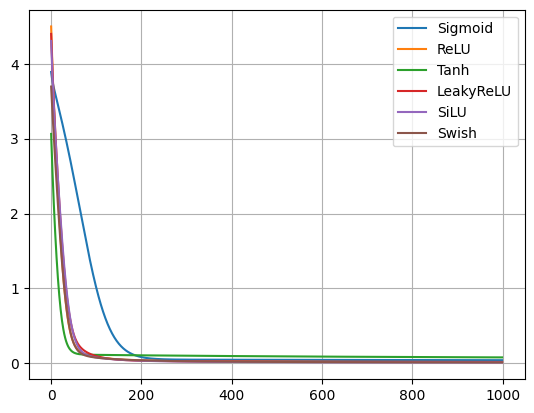

In [20]:
plot_losses(losses_b)

### ReLU + Dropout + BatchNorm

In [21]:
class MlpDropoutBatch(nn.Module):
    def __init__(self,input_size=10, hidden_size=32, output_size=1, activation="ReLU"):
        super(MlpDropoutBatch, self).__init__()
        self.activation = activators.get(activation,None)
        if self.activation is None :
            raise ValueError(f"Undefined activator '{activation}'")
        # Dropout - методика випадкового вилучення нейронів під час навчання
        # її використання розрізняє процеси навчання та використання
        self.hidden  = nn.Linear(input_size, hidden_size)
        self.batch   = nn.BatchNorm1d(hidden_size)
        self.dropout = nn.Dropout(p=0.3)
        self.output  = nn.Linear(hidden_size, output_size)

    def forward(self, x, mode='test') :
        x = self.hidden(x)
        x = self.batch(x)
        x = self.activation(x)
        if mode != 'test' :
            x = self.dropout(x)
        x = self.output(x)    
        return x

In [22]:
mlps_db = { k: MlpDropoutBatch(activation=k) for k in activators.keys() }
losses_db, predictions_db = train_models_set(mlps_db, xtrain, ytrain)
print(*zip(*(predictions_db[k][:5] for k in mlps_db.keys() ), ytest[:5]),sep='\n')
score_table(ytest, predictions_db)

(tensor([2.6416]), tensor([2.8920]), tensor([2.8252]), tensor([2.7970]), tensor([2.7061]), tensor([2.7868]), tensor([2.7220]))
(tensor([1.3324]), tensor([1.2584]), tensor([1.3207]), tensor([1.2602]), tensor([1.2717]), tensor([1.2877]), tensor([1.1580]))
(tensor([0.8857]), tensor([0.7148]), tensor([1.0397]), tensor([0.6978]), tensor([0.7900]), tensor([0.8036]), tensor([0.7431]))
(tensor([3.2071]), tensor([3.6838]), tensor([3.6559]), tensor([3.6206]), tensor([3.7341]), tensor([3.7163]), tensor([3.7869]))
(tensor([2.4596]), tensor([2.4927]), tensor([2.9024]), tensor([2.4667]), tensor([2.5222]), tensor([2.5766]), tensor([2.4418]))


|Активація|MAE|R²|
|-|-|-|
|Sigmoid|0.2536882162094116|0.9640985131263733|
|ReLU|0.18738077580928802|0.9862127900123596|
|Tanh|0.24708440899848938|0.9697025418281555|
|LeakyReLU|0.19355370104312897|0.9856395125389099|
|SiLU|0.17860181629657745|0.9884637594223022|
|Swish|0.1780591607093811|0.9881184101104736|

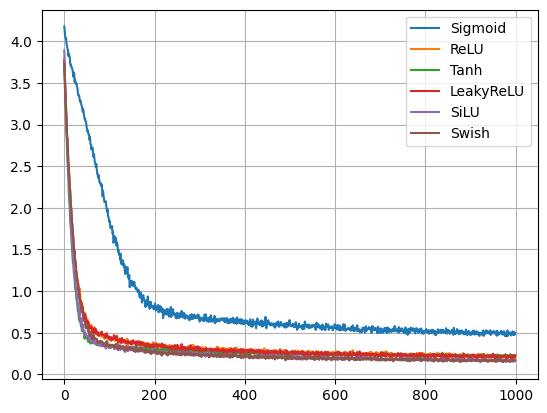

In [24]:
plot_losses(losses_db)

## Завдання 4
Зробіть підсумкове порівняння всіх варіантів моделі.
- Об'єднайте результати у зведену таблицю:

|Конфігурація|MAE|R²|
|-|-|-|
|ReLU|...|...|
|ReLU + Dropout|...|...|
|ReLU + BatchNorm|...|...|
|ReLU + Dropout + BatchNorm|...|...|

- Визначте, яка комбінація дає найбільш стійке навчання.
- Сформулюйте короткий висновок (3-4 речення) у стилі технічного звіту.

In [29]:
md(f"""|Конфігурація|MAE|R²|
|-|-|-|
|ReLU|{sm.mean_absolute_error(ytest,predictions["ReLU"])}|{1}|
|ReLU + Dropout|{sm.mean_absolute_error(ytest,predictions_d["ReLU"])}|...|
|ReLU + BatchNorm|{sm.mean_absolute_error(ytest,predictions_b["ReLU"])}|...|
|ReLU + Dropout + BatchNorm|{sm.mean_absolute_error(ytest,predictions_db["ReLU"])}|...|""")

|Конфігурація|MAE|R²|
|-|-|-|
|ReLU|0.13891658186912537|1|
|ReLU + Dropout|0.1439465582370758|...|
|ReLU + BatchNorm|0.17802032828330994|...|
|ReLU + Dropout + BatchNorm|0.18738077580928802|...|